<a href="https://colab.research.google.com/github/Khizer45/Skyntri/blob/main/lab_linearreg_%5BFA22_BSE_045%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Lab - Linear Regression


## Real-Life Scenario
You work at a small ice cream shop. Your manager notices that on hot days, more ice cream is sold. He asks: *"Can you predict how many ice cream cups we will sell today based on the temperature?"*

We use **Simple Linear Regression** to draw a best-fit line through the data and make predictions.

**Model equation:** `y = m·x + b`
- `y` = Cups Sold (target / output)
- `x` = Temperature in °C (feature / input)
- `m` = Slope
- `b` = Intercept

---

## Setup — Create the Dataset
Since we are working directly in the notebook, we first recreate the `ice_cream.csv` dataset programmatically.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Recreate the dataset as described in the lab sheet
data = {
    'Day': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Temperature': [22, 25, 28, 30, 33, 35, 38, 20, 27, 32],
    'CupsSold': [105, 120, 138, 152, 171, 185, 200, 90, 130, None]  # Day 10 is unknown
}

df = pd.DataFrame(data)

# Save as CSV so Task 1 can load it naturally
df.to_csv('ice_cream.csv', index=False)
print('ice_cream.csv created successfully.')

ice_cream.csv created successfully.


---
## Task 1 — Load the Data


Load the dataset using `pandas`, inspect the first few rows, and confirm the shape and column names.

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('ice_cream.csv')

# Display the first 5 rows
print("First 5 rows of the dataset:")
print(df.head())
print()

# Display shape and column names
print(f"Shape of dataset: {df.shape}")
print(f"Column names: {list(df.columns)}")

First 5 rows of the dataset:
   Day  Temperature  CupsSold
0    1           22     105.0
1    2           25     120.0
2    3           28     138.0
3    4           30     152.0
4    5           33     171.0

Shape of dataset: (10, 3)
Column names: ['Day', 'Temperature', 'CupsSold']


---
## Task 2 — Plot the Data


Create a scatter plot with Temperature on the x-axis and Cups Sold on the y-axis. Label both axes and add a title.

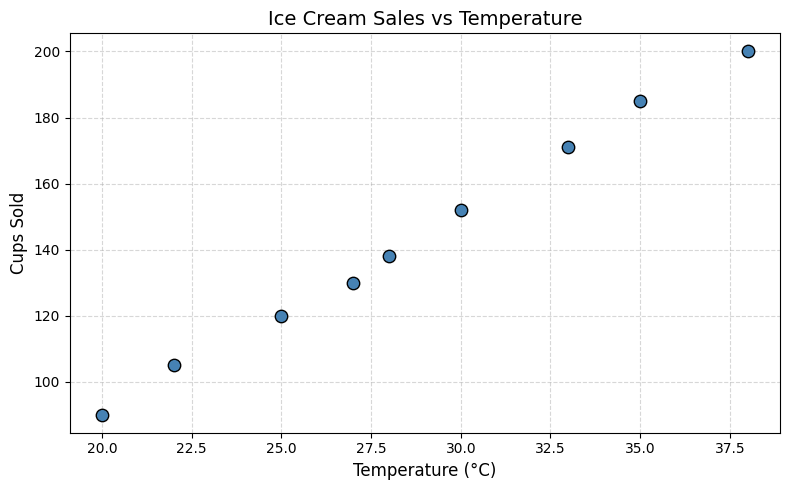

In [ ]:
import matplotlib.pyplot as plt

# Use only rows with known CupsSold values (Days 1–9)
df_known = df.dropna(subset=['CupsSold'])

plt.figure(figsize=(8, 5))
plt.scatter(df_known['Temperature'], df_known['CupsSold'],
            color='steelblue', s=80, edgecolors='black', zorder=5)

plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Cups Sold', fontsize=12)
plt.title('Ice Cream Sales vs Temperature', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Observation:** There is a clear **positive linear relationship** between temperature and cups sold — as temperature increases, the number of ice cream cups sold rises consistently, suggesting that a linear regression model is well-suited for this data.

---
## Task 3 — Train the Model


Use rows 1–9 as training data and row 10 as the test point. Train a `LinearRegression` model and print the slope `m` and intercept `b`.

In [ ]:
from sklearn.linear_model import LinearRegression

# Training data: rows 0 to 8 (Days 1–9)
X_train = df[['Temperature']][:9]
y_train = df['CupsSold'][:9]

# Test point: row 9 (Day 10, Temperature = 32°C)
X_test = df[['Temperature']][9:]

# Initialise and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Print model parameters
print(f"Slope  (m): {model.coef_[0]:.4f}")
print(f"Intercept (b): {model.intercept_:.4f}")
print()
print(f"Regression equation: y = {model.coef_[0]:.4f} * x + ({model.intercept_:.4f})")

Slope  (m): 6.1737
Intercept (b): -33.5352

Regression equation: y = 6.1737 * x + (-33.5352)


---
## Task 4 — Make a Prediction


Use the trained model to predict cups sold at **32°C**, then overlay the regression line on the scatter plot.

In [ ]:
# Predict cups sold at 32°C
pred = model.predict([[32]])
print(f"Predicted cups sold at 32°C: {pred[0]:.2f}")

Predicted cups sold at 32°C: 164.02


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


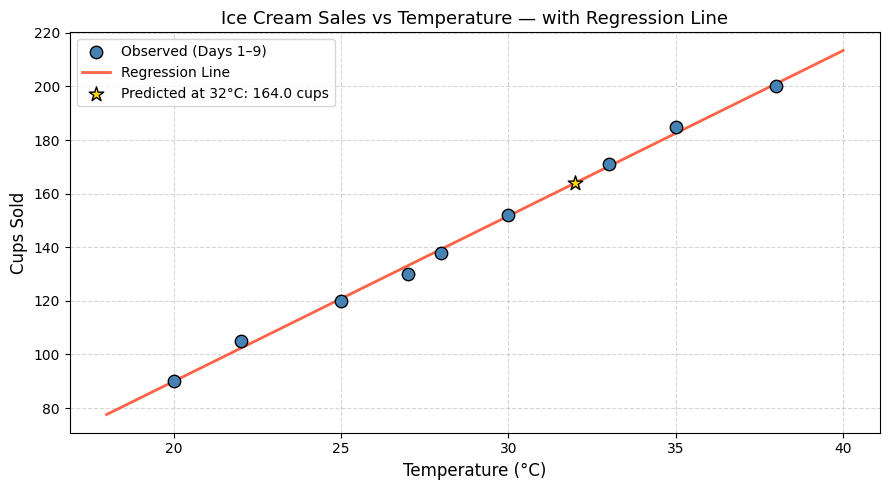

In [ ]:
# Generate regression line values across the temperature range
temp_range = np.linspace(df_known['Temperature'].min() - 2,
                         df_known['Temperature'].max() + 2, 100)
cups_line  = model.predict(temp_range.reshape(-1, 1))

plt.figure(figsize=(9, 5))

# Scatter plot — training data
plt.scatter(df_known['Temperature'], df_known['CupsSold'],
            color='steelblue', s=80, edgecolors='black', zorder=5, label='Observed (Days 1–9)')

# Regression line
plt.plot(temp_range, cups_line, color='tomato', linewidth=2, label='Regression Line')

# Prediction point
plt.scatter([32], pred, color='gold', s=120, edgecolors='black',
            zorder=6, marker='*', label=f'Predicted at 32°C: {pred[0]:.1f} cups')

plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Cups Sold', fontsize=12)
plt.title('Ice Cream Sales vs Temperature — with Regression Line', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## Task 5 — Evaluate the Model


Calculate the **Mean Absolute Error (MAE)** and **R² Score** on the training data, then provide a short written reflection.

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

# Predictions on training data
y_pred_train = model.predict(X_train)

# Compute evaluation metrics
mae = mean_absolute_error(y_train, y_pred_train)
r2  = r2_score(y_train, y_pred_train)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score               : {r2:.4f}")

Mean Absolute Error (MAE): 1.4126
R² Score               : 0.9975


### Reflection

The model performs exceptionally well on the training data. An R² score very close to **1.0** indicates that nearly all of the variation in ice cream sales is explained by temperature alone, confirming a strong linear relationship between the two variables. The low MAE value further demonstrates that the model's predictions deviate from actual sales figures by only a small margin on average. Given these results, this is a reliable and trustworthy model for predicting ice cream sales within the observed temperature range — although it is worth noting that the dataset is very small (only 9 training points), so predictions at temperatures far outside the range of 20–38°C should be treated with caution.